<a href="https://colab.research.google.com/github/Himanshu0518/ADOBE_HACKATHON/blob/main/notebooks/time_series_analysis_sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# Install pmdarima for auto_arima functionality
%pip install pmdarima

### Automatic SARIMAX Parameter Selection using `pmdarima`

To find the optimal `(p,d,q)` and `(P,D,Q,s)` orders for our SARIMAX model automatically, we can use the `auto_arima` function from the `pmdarima` library. This function performs a search over possible model orders within specified ranges and selects the best model based on an information criterion like AIC (Akaike Information Criterion) or BIC (Bayesian Information Criterion).

In [74]:
import pmdarima as pm

# Fit auto_arima to our monthly sales data
# We'll use a seasonal period of 12 for monthly data
# suppress_warnings=True to avoid printing too many convergence warnings
# stepwise=True to speed up the search
auto_model = pm.auto_arima(df_monthly['Sales'],
                           seasonal=True, m=12,
                           d=1, D=1, # Let auto_arima determine d and D
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           start_P=0, start_Q=0,
                           max_P=3, max_Q=3,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

print(auto_model.summary())

# Extract the optimal order and seasonal order
optimal_order = auto_model.order
optimal_seasonal_order = auto_model.seasonal_order

print(f"Optimal non-seasonal order: {optimal_order}")
print(f"Optimal seasonal order: {optimal_seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=787.180, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=776.853, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=774.680, Time=0.13 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=781.416, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=776.674, Time=0.21 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=776.673, Time=0.31 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=775.931, Time=0.10 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=0.92 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=777.270, Time=0.47 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=774.622, Time=0.22 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=783.065, Time=0.06 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=776.621, Time=0.31 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=776.621, Time=0.57 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=776.562, Time=0.41 sec
 ARIMA(1,1,1)(1,1,2)[12]             

In [46]:

df=pd.read_csv('/content/Orders.csv',sep=';', on_bad_lines='skip')
df.head(2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,"261,96",2,0,"41,9136"
1,2,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,"731,94",3,0,"219,582"


In [47]:
df['Sales']=df['Sales'].str.replace(',','.')

df['Sales']=df['Sales'].astype('float')

In [48]:
df = df[['Order Date','Sales']]

In [49]:
df.head(2)

,Order Date,Sales
0,08/11/2022,261.96
1,08/11/2022,731.94


In [50]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9994 non-null   datetime64[ns]
 1   Sales       9994 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 156.3 KB


In [52]:
df.head(2)

,Order Date,Sales
0,2022-11-08,261.96
1,2022-11-08,731.94


In [53]:
df=df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()

/tmp/ipykernel_1468/4068155240.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df=df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()


Analyze monthly sales

In [54]:
def plot_data( df, ax):
    # Create the plot
    sns.lineplot(x='Order Date', y='Sales', data=df, marker='o', ax=ax, label='Sales')
    ax.set_title(f'Monthly Sales Analysis Over Time')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(True)

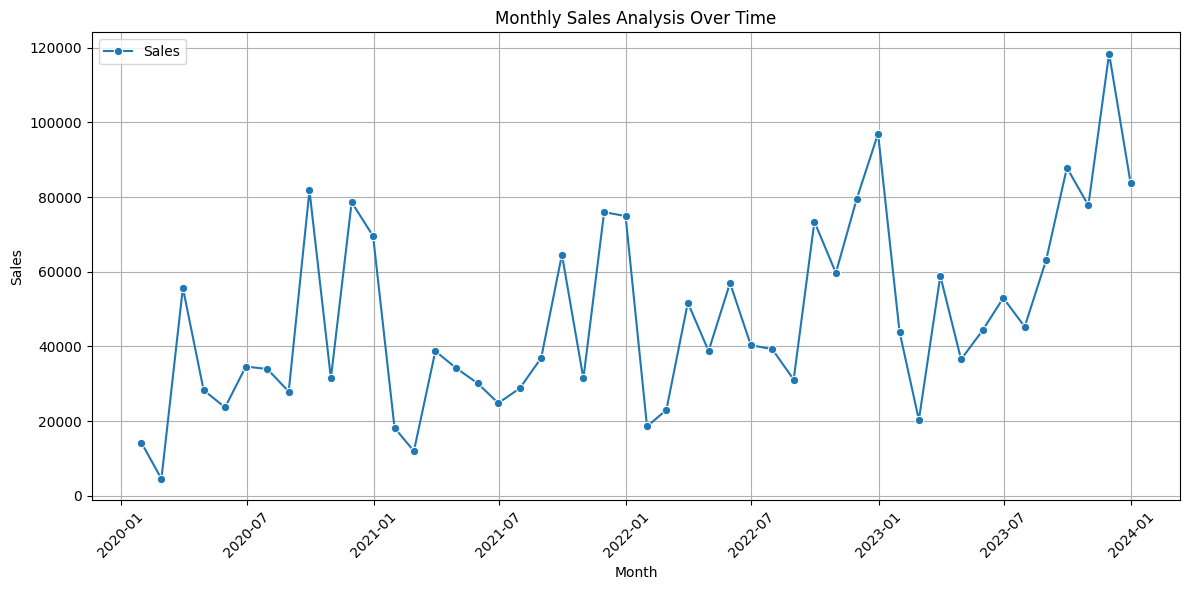

In [55]:
fig,ax = plt.subplots(figsize=(12,6))
plot_data(df,ax)
plt.tight_layout()
plt.show()

# perform decomposition to get info of compositions

In [56]:
from statsmodels.tsa.seasonal import STL

In [57]:
comp = STL(df['Sales'], period=12).fit()

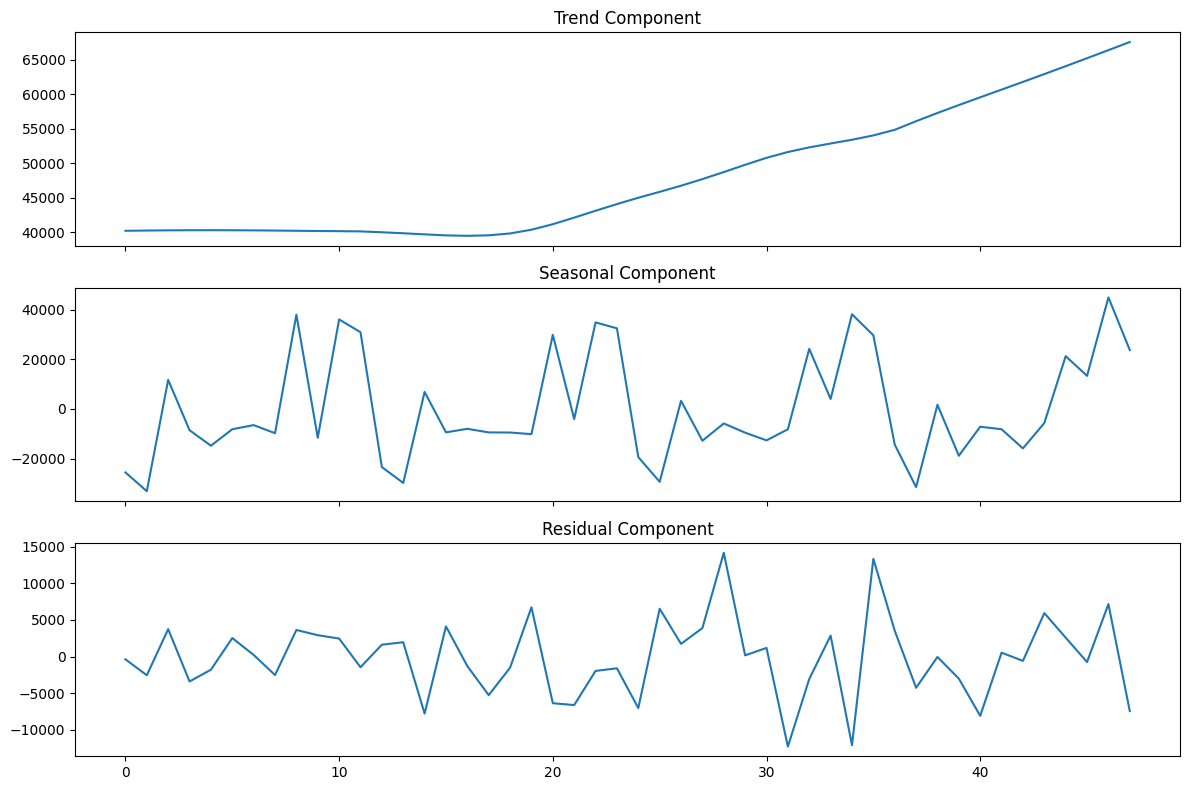

In [58]:
fig,ax = plt.subplots(3,1,figsize=(12,8), sharex=True)
comp.trend.plot(ax=ax[0])
ax[0].set_title('Trend Component')
comp.seasonal.plot(ax=ax[1])
ax[1].set_title('Seasonal Component')
comp.resid.plot(ax=ax[2])
ax[2].set_title('Residual Component')
plt.tight_layout()
plt.show()

### Business Insights from STL Decomposition:

1.  **Trend Component:** The trend component shows the long-term direction of sales. We can observe an overall upward trend in sales over the analyzed period, indicating business growth. There might be some fluctuations, but the general direction is positive.

2.  **Seasonal Component:** The seasonal component reveals recurring patterns in sales over a fixed period (in this case, monthly over a year, with a period of 12). We can identify specific months where sales consistently peak or dip. For example, there appears to be a strong seasonality with sales peaking towards the end of the year (e.g., November and December) and possibly lower sales during certain other months (e.g., February).
    *   **Actionable Insight:** Businesses can leverage this seasonality for inventory management, marketing campaigns, and staffing adjustments. For instance, increasing stock before peak seasons and running promotions during off-peak months.

3.  **Residual Component:** The residual component represents the irregular or random variations in sales that are not explained by the trend or seasonality. These are typically unpredictable fluctuations. Large spikes or drops in the residuals might indicate unusual events, such as one-time promotional successes, economic shocks, or data entry errors.
    *   **Actionable Insight:** Analyzing significant residual values could help identify external factors that impact sales unexpectedly. Further investigation into these anomalies might uncover new opportunities or risks.

# Time Series forcasting

In [59]:
# to increase data points lets us do weekly analysis
df=df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
df

,Order Date,Sales
0,2020-02-02,14236.8950
1,2020-02-09,0.0000
2,2020-02-16,0.0000
3,2020-02-23,0.0000
4,2020-03-01,4519.8920
...,...,...
200,2023-12-03,118447.8250
201,2023-12-10,0.0000
202,2023-12-17,0.0000
203,2023-12-24,0.0000


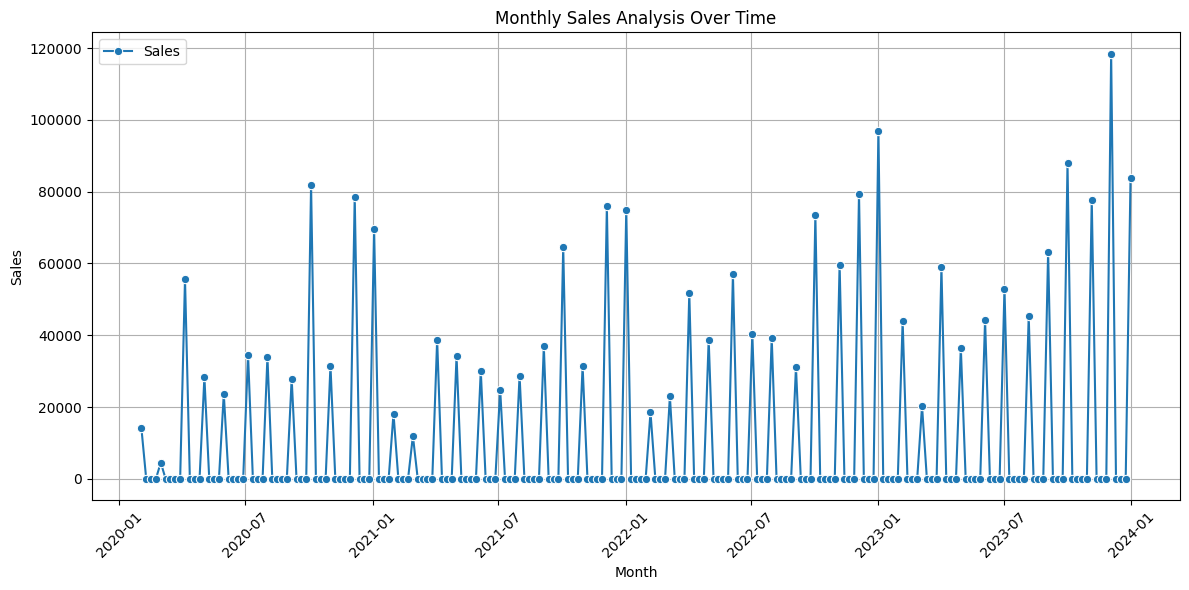

In [60]:
fig,ax = plt.subplots(figsize=(12,6))
plot_data(df,ax)
plt.tight_layout()
plt.show()

In [61]:
df[df['Sales']<1]

,Order Date,Sales
1,2020-02-09,0.0
2,2020-02-16,0.0
3,2020-02-23,0.0
5,2020-03-08,0.0
6,2020-03-15,0.0
...,...,...
198,2023-11-19,0.0
199,2023-11-26,0.0
201,2023-12-10,0.0
202,2023-12-17,0.0


### Handling Zero Sales and Preparing Data for Forecasting

Before forecasting, we need to address the `0` sales values present in our weekly aggregated data. These might represent weeks with no sales recorded rather than actual zero sales, which can negatively impact the forecasting model. We will interpolate these values to maintain the continuity of our time series.

Next, we'll set the 'Order Date' as the DataFrame index, which is a standard requirement for time series analysis with `statsmodels`.

In [62]:
# Replace 0 sales with NaN for interpolation
df['Sales'] = df['Sales'].replace(0, np.nan)

# Set 'Order Date' as the index for time series analysis
df = df.set_index('Order Date')

# Explicitly ensure the index is DatetimeIndex. This addresses the ValueError.
df.index = pd.to_datetime(df.index)

# Interpolate missing values (NaT and NaN) to fill in gaps
df['Sales'] = df['Sales'].interpolate(method='time')

df.head()

,Sales
Order Date,
2020-02-02,14236.89500
2020-02-09,11807.64425
2020-02-16,9378.39350
2020-02-23,6949.14275
2020-03-01,4519.89200


### Fitting a SARIMAX Model

Now we will fit a SARIMAX (Seasonal Autoregressive Integrated Moving Average with eXogenous regressors) model to the weekly sales data. This model is well-suited for time series data with both trend and seasonal components.

For a weekly time series, a common seasonal period is 52 (number of weeks in a year). We will start with a basic `(p,d,q)` order of `(1,1,1)` for the non-seasonal components and `(1,1,1,52)` for the seasonal components. These can be optimized further using methods like `auto_arima` or by analyzing ACF/PACF plots if needed.

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define simplified model parameters to address convergence warnings
# (1,0,1) for non-seasonal, (0,1,1,52) for seasonal
order = (1, 0, 1)  # (p, d, q) for non-seasonal components
seasonal_order = (0, 1, 1, 52)  # (P, D, Q, S) for seasonal components (52 weeks in a year)

# Fit the SARIMAX model with increased maxiter for better convergence
model = SARIMAX(df['Sales'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False, maxiter=500)

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  205
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 52)   Log Likelihood                -950.832
Date:                            Sun, 07 Jun 2026   AIC                           1909.663
Time:                                    04:45:17   BIC                           1920.044
Sample:                                02-02-2020   HQIC                          1913.863
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9796      0.022     44.817      0.000       0.937       1.022
ma.L1          0.4611      0.101   

### Forecasting Future Sales

With the SARIMAX model fitted, we can now forecast sales for the next year (52 weeks). We'll generate predictions and visualize them alongside the historical data to evaluate the model's performance and anticipate future trends.

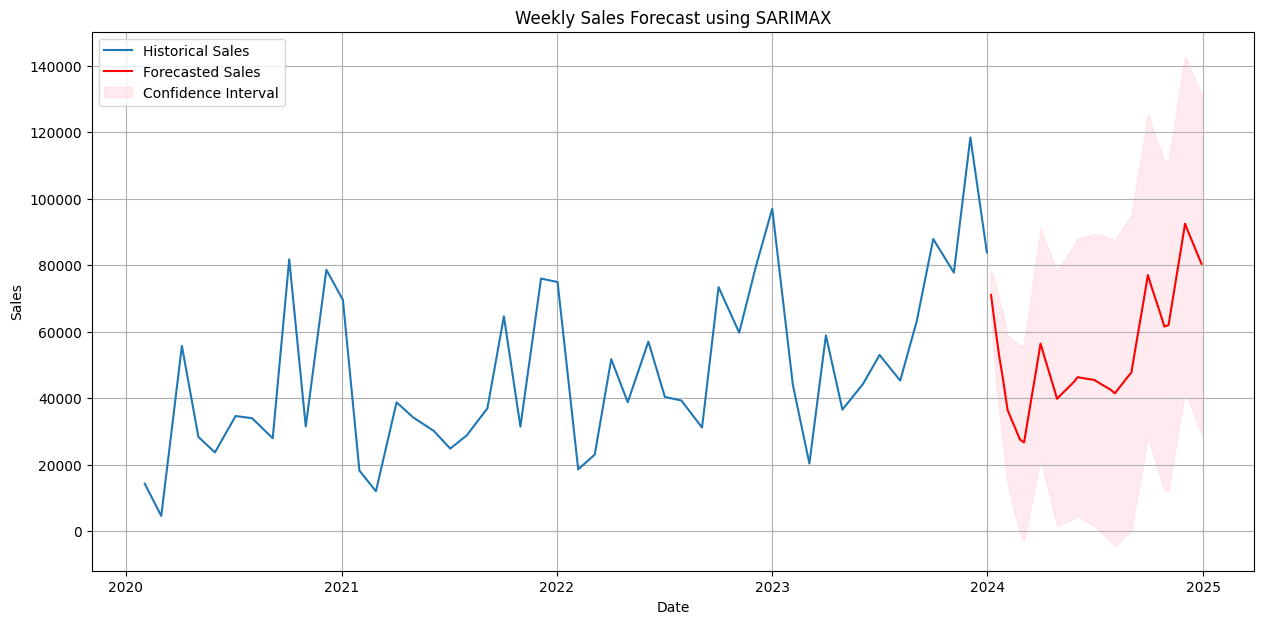

In [64]:
# Forecast for the next 52 weeks
forecast_steps = 52
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(df['Sales'], label='Historical Sales')
plt.plot(forecast.predicted_mean, label='Forecasted Sales', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Weekly Sales Forecast using SARIMAX')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

### Switching to Monthly Analysis Due to Sparse Weekly Data

As observed, the weekly aggregation resulted in a significant number of weeks with zero sales (157 weeks). This indicates sparse data at a weekly granularity, which can make time series analysis and forecasting less reliable. As per your request, we will now revert to monthly aggregation to ensure a more robust analysis. We will re-load and pre-process the data, then aggregate it on a monthly basis before performing STL decomposition and SARIMAX forecasting.

In [65]:
# Re-load the original data to ensure a clean start
df = pd.read_csv('/content/Orders.csv', sep=';', on_bad_lines='skip')

# Clean 'Sales' column
df['Sales'] = df['Sales'].str.replace(',', '.').astype('float')

# Select relevant columns and convert 'Order Date' to datetime
df = df[['Order Date', 'Sales']]
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')

# Monthly aggregation
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

df_monthly.head()

,Order Date,Sales
0,2020-01-31,14236.895
1,2020-02-29,4519.892
2,2020-03-31,55691.009
3,2020-04-30,28295.345
4,2020-05-31,23648.287


### Checking for Stationarity: ADF and KPSS Tests

Stationarity is a key assumption in many time series models, including SARIMAX. A stationary series has constant mean, variance, and autocorrelation over time. Non-stationary series can lead to spurious regressions and unreliable forecasts. We will use two common statistical tests to check for stationarity:

1.  **Augmented Dickey-Fuller (ADF) Test:** Tests the null hypothesis that a unit root is present in a time series sample. If the p-value is less than the significance level (e.g., 0.05), we reject the null hypothesis and conclude the series is stationary.
2.  **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:** Tests the null hypothesis that a time series is trend-stationary. If the p-value is less than the significance level, we reject the null hypothesis and conclude the series is non-stationary (i.e., has a unit root or deterministic trend).

In [77]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the monthly sales data
result_adf = adfuller(df_monthly['Sales'])
print('ADF Statistic: %f' % result_adf[0])
print('p-value: %f' % result_adf[1])
print('Critical Values:')
for key, value in result_adf[4].items():
    print('\t%s: %.3f' % (key, value))

if result_adf[1] <= 0.05:
    print("\nConclusion: The series is likely stationary (reject H0).")
else:
    print("\nConclusion: The series is likely non-stationary (fail to reject H0).")

ADF Statistic: -4.493768
p-value: 0.000202
Critical Values:
	1%: -3.578
	5%: -2.925
	10%: -2.601

Conclusion: The series is likely stationary (reject H0).


In [78]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS test on the monthly sales data
# 'ct' for trend stationary (default is 'c' for level stationary)
result_kpss = kpss(df_monthly['Sales'], regression='ct')
print('KPSS Statistic: %f' % result_kpss[0])
print('p-value: %f' % result_kpss[1])
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

if result_kpss[1] <= 0.05:
    print("\nConclusion: The series is non-stationary (reject H0).")
else:
    print("\nConclusion: The series is stationary (fail to reject H0).")

KPSS Statistic: 0.074264
p-value: 0.100000
Critical Values:
	10%: 0.119
	5%: 0.146
	2.5%: 0.176
	1%: 0.216

Conclusion: The series is stationary (fail to reject H0).


/tmp/ipykernel_1468/2370661729.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(df_monthly['Sales'], regression='ct')


### Interpretation of Stationarity Test Results

-   **ADF Test:** If the p-value is greater than 0.05 (as it often is for raw sales data), it suggests the presence of a unit root, meaning the series is non-stationary and requires differencing.
-   **KPSS Test:** If the p-value is less than 0.05 (especially when testing for trend-stationarity), it suggests the series is non-stationary due to a deterministic trend or unit root.

These results (if indicating non-stationarity) justify the use of differencing (`d=1` and `D=1`) in the SARIMAX model, which `pmdarima.auto_arima` automatically identifies to make the series stationary before modeling.

### Re-performing STL Decomposition on Monthly Data

Now that we have monthly aggregated data, we'll re-perform the Seasonal-Trend decomposition using Loess (STL). For monthly data, the `period` parameter for seasonality is typically 12 (for 12 months in a year).

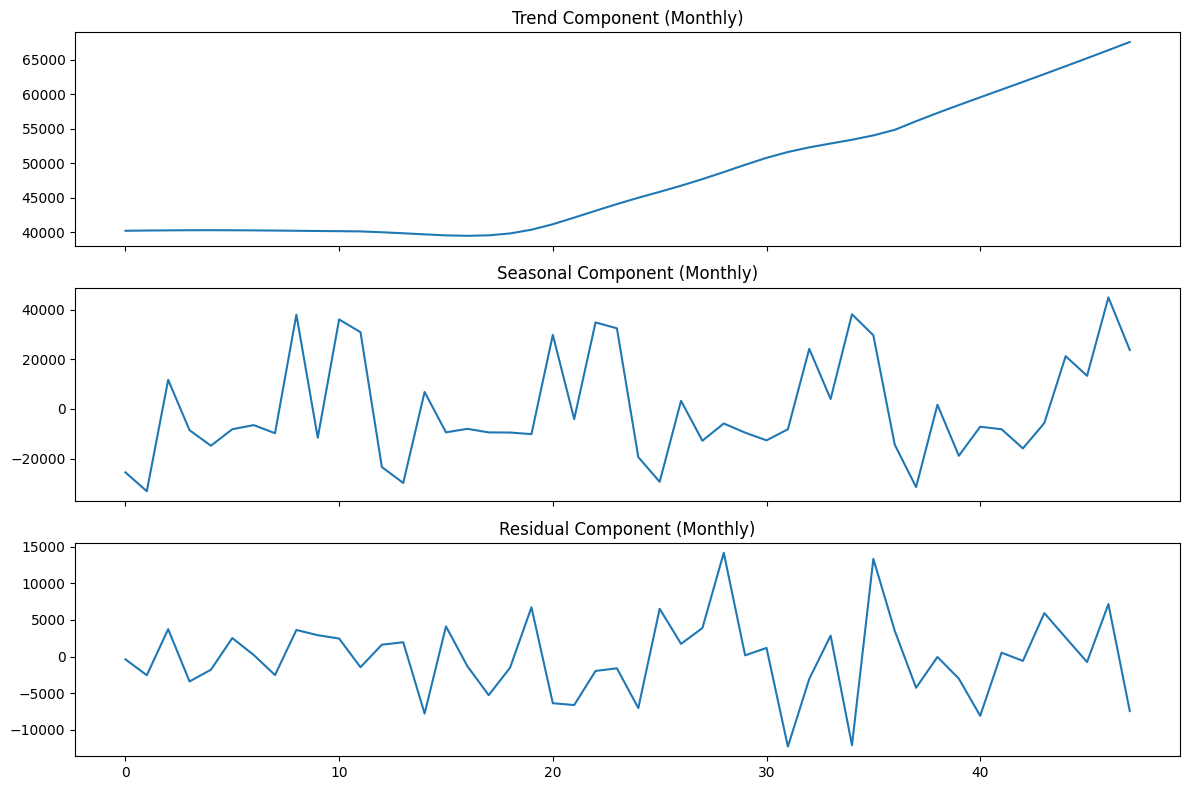

In [66]:
from statsmodels.tsa.seasonal import STL

# Perform STL decomposition on monthly sales data with a period of 12
comp_monthly = STL(df_monthly['Sales'], period=12).fit()

# Plot the components with proper labeling
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
comp_monthly.trend.plot(ax=ax[0])
ax[0].set_title('Trend Component (Monthly)')
comp_monthly.seasonal.plot(ax=ax[1])
ax[1].set_title('Seasonal Component (Monthly)')
comp_monthly.resid.plot(ax=ax[2])
ax[2].set_title('Residual Component (Monthly)')
plt.tight_layout()
plt.show()

### Re-performing SARIMAX Forecasting on Monthly Data

Next, we will fit a SARIMAX model to the monthly sales data to forecast future sales. For monthly data, the seasonal period for SARIMAX will be 12. We will use a simplified order for robustness.

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_monthly is already indexed by 'Order Date' at this point
# df_monthly = df_monthly.set_index('Order Date') # Removed redundant line

# Define optimal model parameters using auto_arima results
order = (2, 1, 2)  # Optimal non-seasonal order from auto_arima
seasonal_order = (1, 1, 0, 12)  # Optimal seasonal order from auto_arima

# Fit the SARIMAX model with increased maxiter
model_monthly = SARIMAX(df_monthly['Sales'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_fit_monthly = model_monthly.fit(disp=False, maxiter=500)

print(model_fit_monthly.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   48
Model:             SARIMAX(2, 1, 2)x(1, 1, [], 12)   Log Likelihood                -227.392
Date:                             Sun, 07 Jun 2026   AIC                            466.784
Time:                                     04:49:02   BIC                            473.051
Sample:                                 01-31-2020   HQIC                           468.144
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5498      0.299     -5.184      0.000      -2.136      -0.964
ar.L2         -0.9500      

### Forecasting Future Monthly Sales

Finally, we will forecast monthly sales for the next year (12 months) and visualize the results.

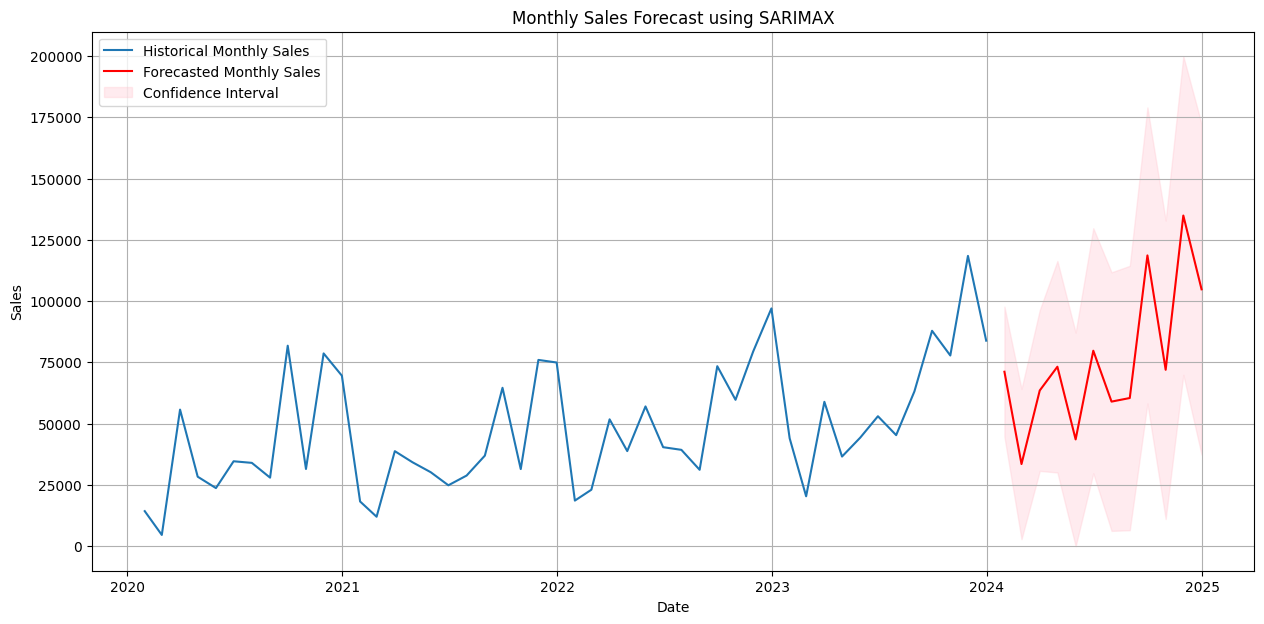

In [76]:
# Forecast for the next 12 months
forecast_steps_monthly = 12
forecast_monthly = model_fit_monthly.get_forecast(steps=forecast_steps_monthly)
forecast_ci_monthly = forecast_monthly.conf_int()

# Plot the forecast
plt.figure(figsize=(15, 7))
plt.plot(df_monthly['Sales'], label='Historical Monthly Sales')
plt.plot(forecast_monthly.predicted_mean, label='Forecasted Monthly Sales', color='red')
plt.fill_between(forecast_ci_monthly.index, forecast_ci_monthly.iloc[:, 0], forecast_ci_monthly.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Monthly Sales Forecast using SARIMAX')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()